# WASP-121b multi-instrument eclipse mapping

This notebook is a teaching and audit guide for the WASP-121b study in `robert-mapping`. It is written so that a student can read each section, run the data checks, and then adapt the workflow to a new planet.

The default notebook is safe. It reads local products, checks them, and makes diagnostic plots. It does not run an inference or a simulation. Set `RUN_INFERENCE = True` only after the input and systematics checks are complete.

## Learning goals

By the end of this notebook you should be able to:

1. State the science question and separate unique observations from duplicate reductions.
2. Track time systems, masks, units, wavelength ranges, and published model columns.
3. Inspect raw or processed white light curves before fitting a map.
4. Count transits and eclipses in a full phase curve.
5. Explain why one brightness map is made for each instrument, detector, order, visit, or wavelength bin before a joint atmospheric model.
6. Describe the map, brightness-temperature, longitude, and hot-spot outputs.
7. Choose a systematics model that matches the instrument.
8. Run small, reproducible batches with a hard three-CPU limit.
9. Apply the same checks to a new planet.

## 1. Scientific question and study design

WASP-121b is a useful test case because it has optical, near-infrared, and mid-infrared light curves. Different wavelengths usually probe different atmospheric pressures. A wavelength-dependent eclipse map can therefore test whether the hot-spot longitude and the day-night brightness pattern change with altitude.

The first question is simple:

> Do the data support a longitudinal brightness pattern, and does that pattern change with wavelength or instrument?

The second question is harder:

> Can the wavelength-dependent maps be combined into a physically useful vertical picture?

We answer these questions in stages. First fit each unique light curve or spectral bin separately. Then compare the maps. Only after that should we fit a hierarchical model with shared orbital parameters and wavelength-dependent map parameters. A single map for all wavelengths can hide real vertical structure and can also force incompatible systematics models into one fit.

## 2. Unique observations versus duplicate reductions

A reduction is not a new observation. Two pipelines can process the same photons. Their products are useful for a reduction comparison. Do not put both products in one independent likelihood unless you model their covariance.

| Photon set | Coverage | Current use |
| --- | --- | --- |
| JWST/NIRSpec G395H GO-1729 | Full phase; NRS1 and NRS2 | White and 349 spectral channels are prepared |
| JWST/NIRISS SOSS GTO-1201 | Full phase; orders 1 and 2 | Local processed white curves need a provenance audit |
| JWST/MIRI LRS GO-2961 | One eclipse; broadband and 47 channels | Prepared eclipse-only inputs |
| HST/WFC3 G141 GO-15134, 2018 | Full phase | Broadband and 12 spectral channels are prepared; time conversion is still needed |
| HST/WFC3 G141 GO-15134, 2019 | Full phase | Broadband is usable after time conversion; the public spectral archive has bad 2018 timestamps and is not fit-ready |
| HST/WFC3 G102 GO-15135 | Two eclipse visits | Archive reduction is required |
| HST/WFC3 G141 GO-14767 | One independent eclipse | Archive reduction is required |
| Spitzer/IRAC P-13242 | 3.6 and 4.5 micron full phases | Archive reduction is required |
| Spitzer/IRAC P-13044 | 3.6 and 4.5 micron eclipses | Archive reduction is required |
| TESS Sector 7 | Binned optical phase curve | Prepared as a comparison product, not a native time series |
| SMARTS/ANDICAM K band | One eclipse over three nights | Source is local; the weight and systematics model need an audit |

The machine-readable manifest is `literature_data/wasp121b_suite.yml`. It is the source of truth for readiness. A white curve and its spectral channels contain the same photons. Fit them at different analysis stages, not as independent observations.

## 3. Environment and compute safety

Use one environment for all code:

```bash
conda activate eclipse-mapping
python -m pip install -e .
```

This notebook sets common numerical thread variables to three. Keep `compute.threads` and `compute.max_cpus` at three or lower in every YAML file. The default settings below do not import the sampler and do not draw posterior samples.

The three-CPU rule protects a laptop and also makes a local run more similar to a three-core Slurm allocation. On a cluster, request the same number of CPUs and set the same environment variables in the job script.

In [1]:
import os
from pathlib import Path
import tempfile

# Apply the project safety limit before importing numerical libraries.
for _name in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_name] = '3'
os.environ['XLA_FLAGS'] = '--xla_cpu_multi_thread_eigen=false intra_op_parallelism_threads=3'
os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'robert_mapping_mpl_cache'))

import json
import numpy as np
import matplotlib.pyplot as plt

MEDIUMPURPLE = 'mediumpurple'
PURPLE_CMAP = plt.get_cmap('Purples_r')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'font.size': 10,
    'axes.prop_cycle': plt.cycler(color=['mediumpurple', 'rebeccapurple', 'plum', 'darkslateblue']),
})

def locate_repo():
    hinted = os.environ.get('ROBERT_MAPPING_REPO')
    candidates = []
    if hinted:
        candidates.append(Path(hinted).expanduser())
    here = Path.cwd()
    candidates.extend([here, *here.parents])
    for candidate in candidates:
        if (candidate / 'literature_data').is_dir() and (candidate / 'src').is_dir():
            return candidate.resolve()
    raise FileNotFoundError('Could not find the robert-mapping repository. Run this notebook inside the repository or set ROBERT_MAPPING_REPO.')

REPO = locate_repo()
print('Repository:', REPO)
print('Python thread limit:', os.environ['OMP_NUM_THREADS'])
print('Map colour:', MEDIUMPURPLE)
print('Hotter and brighter map pixels use lighter colours through Purples_r.')

Matplotlib is building the font cache; this may take a moment.


Repository: /Users/jaketaylor/Dropbox/eclipse-mapping
Python thread limit: 3
Map colour: mediumpurple
Hotter and brighter map pixels use lighter colours through Purples_r.


## 4. Configuration anatomy

The YAML configuration is the main teaching interface. Keep the names explicit. A student should be able to identify the data file, orbital assumptions, map representation, systematics terms, sampler settings, CPU limit, and output directory without reading the source code.

- `project`: name, seed, and a short description.
- `data`: file format, columns, time unit, exposure time, and normalisation.
- `system`: period, transit epoch, geometry, stellar properties, and limb darkening.
- `map`: harmonic or pixel representation, degree, positivity, and regularisation.
- `model`: likelihood, noise model, light-travel delay, exposure integration, and fitted nuisance parameters.
- `systematics`: baseline, ramp, detector regressors, and composition of multiplicative terms.
- `inference`: sampler, chains, warmup, draws, and target acceptance.
- `compute`: CPU profile, JAX platform, 64-bit mode, and quadrature.
- `output`: results path, saved files, and the best-fit colour.

The dictionary in the next cell mirrors the important fields. It is an in-memory example. It does not replace a YAML file and it is not passed to the sampler.

In [2]:
STUDY_CONFIG = {
    'project': {
        'name': 'wasp121b-student-study',
        'seed': 20260829,
        'description': 'Auditable multi-instrument eclipse-mapping study',
    },
    'data': {
        'format': 'prepared NPZ or source table',
        'time_unit': 'day',
        'normalise': 'none unless the source product says otherwise',
    },
    'system': {
        'period_days': 1.27492504,
        'transit_epoch_bjd_tdb': 2458119.72074,
        'a_over_rstar': 3.80,
        'radius_ratio': 0.123,
        'inclination_degrees': 88.1,
        'eccentricity': 0.0,
    },
    'map': {
        'representation': 'positive_harmonics_or_lognormal_pixels',
        'harmonic_degree': 2,
        'active_harmonics': [0, 2, 3],
        'latitude_warning': 'north-south structure is weakly constrained by a phase curve',
    },
    'model': {
        'likelihood': 'independent Gaussian with fitted error scale when justified',
        'include_light_delay': True,
        'integrate_exposure': True,
    },
    'systematics': {
        'NIRSpec': 'time baseline plus jitter x/y terms and uncertainty scale',
        'MIRI': 'time baseline plus exponential ramp and uncertainty scale',
        'HST': 'visit/orbit baseline and scan-related terms when available',
        'SOSS': 'recover source regressors before a production fit',
        'TESS': 'phase-folded product; no native detector regressors',
    },
    'inference': {
        'sampler': 'NUTS',
        'chains': 2,
        'warmup': 1000,
        'draws': 1000,
        'target_accept': 0.98,
    },
    'compute': {'profile': 'local', 'platform': 'cpu', 'threads': 3, 'max_cpus': 3, 'x64': True},
    'output': {'best_fit_color': 'mediumpurple', 'run_inference': False, 'run_simulations': False},
}
print(json.dumps(STUDY_CONFIG, indent=2))

{
  "project": {
    "name": "wasp121b-student-study",
    "seed": 20260829,
    "description": "Auditable multi-instrument eclipse-mapping study"
  },
  "data": {
    "format": "prepared NPZ or source table",
    "time_unit": "day",
    "normalise": "none unless the source product says otherwise"
  },
  "system": {
    "period_days": 1.27492504,
    "transit_epoch_bjd_tdb": 2458119.72074,
    "a_over_rstar": 3.8,
    "radius_ratio": 0.123,
    "inclination_degrees": 88.1,
    "eccentricity": 0.0
  },
  "map": {
    "representation": "positive_harmonics_or_lognormal_pixels",
    "harmonic_degree": 2,
    "active_harmonics": [
      0,
      2,
      3
    ],
    "latitude_warning": "north-south structure is weakly constrained by a phase curve"
  },
  "model": {
    "likelihood": "independent Gaussian with fitted error scale when justified",
    "include_light_delay": true,
    "integrate_exposure": true
  },
  "systematics": {
    "NIRSpec": "time baseline plus jitter x/y terms and unc

## 5. Build an auditable local inventory

Every record below has a path, a time convention, a correction status, and a mask note. A missing file is a normal result of an inventory check. It is not a reason to create placeholder data.

The prepared NIRSpec and MIRI products retain source-row information and published model columns. The HST and TESS products are published normalised or binned products. The local SOSS products are processed white light curves with incomplete provenance, so they are useful for an early check but are not yet a raw-systematics production input.

In [3]:
def repo_path(*parts):
    return REPO.joinpath(*parts)

DATASET_SPECS = {
    'nirspec_nrs1': {
        'label': 'JWST/NIRSpec G395H NRS1 white',
        'path': repo_path('literature_data', 'WASP-121b', 'JWST-NIRSpec-G395H', 'prepared', 'white_nrs1.npz'),
        'format': 'npz', 'time_system': 'BJD_TDB', 'correction_status': 'source flux with published systematics model',
    },
    'nirspec_nrs2': {
        'label': 'JWST/NIRSpec G395H NRS2 white',
        'path': repo_path('literature_data', 'WASP-121b', 'JWST-NIRSpec-G395H', 'prepared', 'white_nrs2.npz'),
        'format': 'npz', 'time_system': 'BJD_TDB', 'correction_status': 'source flux with published systematics model',
    },
    'miri_broadband': {
        'label': 'JWST/MIRI LRS broadband',
        'path': repo_path('literature_data', 'WASP-121b', 'JWST-MIRI-LRS', 'prepared', 'white_light_curve.npz'),
        'format': 'npz', 'time_system': 'BMJD_TDB', 'correction_status': 'source flux with published polynomial, ramp, and astrophysical models',
    },
    'hst_g141_2018': {
        'label': 'HST/WFC3 G141 2018 full phase',
        'path': repo_path('literature_data', 'WASP-121b', 'HST-WFC3-G141', 'source', 'broadBand_lightCurve_2018.txt'),
        'format': 'text', 'time_system': 'JD_UTC', 'correction_status': 'published normalised broadband source table',
    },
    'hst_g141_2019': {
        'label': 'HST/WFC3 G141 2019 full phase',
        'path': repo_path('literature_data', 'WASP-121b', 'HST-WFC3-G141', 'source', 'broadBand_lightCurve_2019.txt'),
        'format': 'text', 'time_system': 'JD_UTC', 'correction_status': 'published normalised broadband source table',
    },
    'soss_order1': {
        'label': 'JWST/NIRISS SOSS order 1 local processed white',
        'path': repo_path('WASP-121b', 'SOSS', 'W-121b-exoTEDRF-WLC-o1.csv'),
        'format': 'csv', 'time_system': 'BMJD_TDB', 'correction_status': 'local processed product; source regressors not present',
    },
    'soss_order2': {
        'label': 'JWST/NIRISS SOSS order 2 local processed white',
        'path': repo_path('WASP-121b', 'SOSS', 'W-121b-exoTEDRF-WLC-o2.csv'),
        'format': 'csv', 'time_system': 'BMJD_TDB', 'correction_status': 'local processed product; source regressors not present',
    },
    'tess': {
        'label': 'TESS binned optical phase curve',
        'path': repo_path('literature_data', 'WASP-121b', 'TESS', 'prepared', 'white_light_curve.npz'),
        'format': 'npz', 'time_system': 'relative_phase', 'correction_status': 'published phase-folded and binned product',
    },
}

OPTIONAL_DATASETS = {
    'hst_g102': repo_path('literature_data', 'WASP-121b', 'HST-WFC3-G102'),
    'hst_g141_2016': repo_path('literature_data', 'WASP-121b', 'HST-WFC3-G141-2016-Eclipse'),
    'spitzer_full_phase': repo_path('literature_data', 'WASP-121b', 'Spitzer-IRAC-13242'),
    'spitzer_eclipse': repo_path('literature_data', 'WASP-121b', 'Spitzer-IRAC-13044'),
    'smarts_k': repo_path('literature_data', 'WASP-121b', 'SMARTS-2MASS-K', 'source', 'wasp-121.dat'),
}

print('Local white-light inventory')
for key, spec in DATASET_SPECS.items():
    status = 'READY' if spec['path'].is_file() else 'MISSING'
    print(f'{status:7s} {key:18s} {spec["path"]}')
print('\nOptional archive locations')
for key, path in OPTIONAL_DATASETS.items():
    print(f'{"PRESENT" if path.exists() else "NOT LOCAL":10s} {key:22s} {path}')

Local white-light inventory
READY   nirspec_nrs1       /Users/jaketaylor/Dropbox/eclipse-mapping/literature_data/WASP-121b/JWST-NIRSpec-G395H/prepared/white_nrs1.npz
READY   nirspec_nrs2       /Users/jaketaylor/Dropbox/eclipse-mapping/literature_data/WASP-121b/JWST-NIRSpec-G395H/prepared/white_nrs2.npz
READY   miri_broadband     /Users/jaketaylor/Dropbox/eclipse-mapping/literature_data/WASP-121b/JWST-MIRI-LRS/prepared/white_light_curve.npz
READY   hst_g141_2018      /Users/jaketaylor/Dropbox/eclipse-mapping/literature_data/WASP-121b/HST-WFC3-G141/source/broadBand_lightCurve_2018.txt
READY   hst_g141_2019      /Users/jaketaylor/Dropbox/eclipse-mapping/literature_data/WASP-121b/HST-WFC3-G141/source/broadBand_lightCurve_2019.txt
READY   soss_order1        /Users/jaketaylor/Dropbox/eclipse-mapping/WASP-121b/SOSS/W-121b-exoTEDRF-WLC-o1.csv
READY   soss_order2        /Users/jaketaylor/Dropbox/eclipse-mapping/WASP-121b/SOSS/W-121b-exoTEDRF-WLC-o2.csv
READY   tess               /Users/jaketayl

## 6. Load and validate the white light curves

The validation rules are deliberately boring:

- time, flux, and uncertainty must have the same length;
- all retained values must be finite;
- every uncertainty must be positive;
- an explicit source mask must be applied before a fit;
- the time convention must be stored with the record;
- a processed product must not be called raw; and
- a published model must be plotted separately from the measured flux.

The loaders below use only NumPy. This keeps the notebook easy to move to a laptop, a Slurm node, or a new planet.

In [4]:
def valid_rows(time, flux, flux_err, source_mask=None):
    time = np.asarray(time, dtype=float)
    flux = np.asarray(flux, dtype=float)
    flux_err = np.asarray(flux_err, dtype=float)
    if not (time.ndim == flux.ndim == flux_err.ndim == 1):
        raise ValueError('time, flux, and flux_err must be one-dimensional')
    if not (len(time) == len(flux) == len(flux_err)):
        raise ValueError('time, flux, and flux_err must have the same length')
    mask = np.isfinite(time) & np.isfinite(flux) & np.isfinite(flux_err) & (flux_err > 0)
    if source_mask is not None:
        mask &= np.asarray(source_mask, dtype=bool)
    return mask

def record_from_arrays(key, spec, time, flux, flux_err, source_mask=None, **extra):
    mask = valid_rows(time, flux, flux_err, source_mask)
    item = {
        'key': key, 'label': spec['label'], 'time': np.asarray(time)[mask].astype(float),
        'flux': np.asarray(flux)[mask].astype(float), 'flux_err': np.asarray(flux_err)[mask].astype(float),
        'time_system': spec['time_system'], 'correction_status': spec['correction_status'],
        'source_path': spec['path'], 'source_rows': len(np.asarray(time)), 'kept_rows': int(mask.sum()),
        'mask': mask,
    }
    item.update({name: np.asarray(value)[mask] if np.asarray(value).ndim else value for name, value in extra.items()})
    if 'source_row' in item:
        item['source_rows'] = int(np.max(item['source_row'])) + 1
    if spec['time_system'] == 'BMJD_TDB':
        item['phase_bjd'] = item['time'] + 2400000.5
    elif spec['time_system'] in ('BJD_TDB', 'JD_UTC'):
        item['phase_bjd'] = item['time']
    else:
        item['phase_bjd'] = None
    item['x_hours'] = item['time'] * 24.0 if spec['time_system'] == 'relative_phase' else (item['time'] - np.median(item['time'])) * 24.0
    return item

def load_npz_record(key, spec):
    with np.load(spec['path'], allow_pickle=False) as archive:
        time = archive['time']
        flux = archive['flux']
        flux_err = archive['flux_err']
        source_mask = archive['mask'] if 'mask' in archive.files else None
        extra = {}
        if key.startswith('nirspec') and 'published_systematics_model' in archive.files:
            extra['systematics_model'] = archive['published_systematics_model']
            extra['astrophysical_model'] = archive['published_astrophysical_model']
            if 'source_row' in archive.files:
                extra['source_row'] = archive['source_row']
        if key == 'miri_broadband':
            extra['systematics_model'] = archive['published_total_model']
            extra['astrophysical_model'] = archive['published_astrophysical_model']
            extra['polynomial'] = archive['published_polynomial']
            extra['exponential_ramp'] = archive['published_exponential_ramp']
            extra['published_residuals'] = archive['published_residuals']
            if 'source_row' in archive.files:
                extra['source_row'] = archive['source_row']
        if key == 'tess':
            extra['phase_relative_hours'] = archive['phase_relative_time_hours']
    return record_from_arrays(key, spec, time, flux, flux_err, source_mask, **extra)

def load_text_record(key, spec):
    table = np.loadtxt(spec['path'], comments='#', dtype=float)
    if table.ndim != 2 or table.shape[1] < 3:
        raise ValueError(f'Expected three columns in {spec["path"]}')
    return record_from_arrays(key, spec, table[:, 0], table[:, 1], table[:, 2])

def load_csv_record(key, spec):
    table = np.loadtxt(spec['path'], delimiter=',', skiprows=1, dtype=float)
    if table.ndim != 2 or table.shape[1] < 3:
        raise ValueError(f'Expected three columns in {spec["path"]}')
    return record_from_arrays(key, spec, table[:, 0], table[:, 1], table[:, 2])

DATA = {}
for key, spec in DATASET_SPECS.items():
    if not spec['path'].is_file():
        continue
    try:
        if spec['format'] == 'npz':
            DATA[key] = load_npz_record(key, spec)
        elif spec['format'] == 'text':
            DATA[key] = load_text_record(key, spec)
        elif spec['format'] == 'csv':
            DATA[key] = load_csv_record(key, spec)
    except Exception as exc:
        print(f'Could not load {key}: {exc}')

def cadence_seconds(item):
    differences = np.diff(np.sort(item['time']))
    differences = differences[np.isfinite(differences) & (differences > 0)]
    return float(np.median(differences) * 86400.0) if differences.size else float('nan')

print(f'Loaded {len(DATA)} of {len(DATASET_SPECS)} white-light records.')
print(f'{"dataset":18s} {"rows":>6s} {"cadence_s":>11s} {"sigma_ppm":>11s}  time system')
for key, item in DATA.items():
    print(f'{key:18s} {item["kept_rows"]:6d} {cadence_seconds(item):11.3f} {np.median(item["flux_err"])*1e6:11.2f}  {item["time_system"]}')

Loaded 8 of 8 white-light records.
dataset              rows   cadence_s   sigma_ppm  time system
nirspec_nrs1         3428      38.809       91.57  BJD_TDB
nirspec_nrs2         3430      38.809      137.25  BJD_TDB
miri_broadband       1712      13.359      355.26  BMJD_TDB
hst_g141_2018         388     171.008       62.09  JD_UTC
hst_g141_2019         387     171.008       62.09  JD_UTC
soss_order1          3447      38.459       41.43  BMJD_TDB
soss_order2          3447      38.459       73.87  BMJD_TDB
tess                  151     720.000      118.60  relative_phase


## 7. Time systems and masks

The same number is not always the same time.

- NIRSpec stores BJD in the TDB time standard.
- MIRI and local SOSS tables store BMJD_TDB, which means BJD_TDB minus 2400000.5.
- HST source tables label their time as JD_UTC. For a broad event count we can use the source times as an approximation, but a production fit must use the stated time conversion consistently.
- TESS is a phase-folded binned table. It has relative time in hours around transit, not an absolute event timestamp.

NIRSpec and MIRI prepared arrays already apply their source masks. The original source row is retained so that a student can trace every retained point back to the archive file. Never silently replace a rejected value with zero, interpolation, or a model prediction.

In [5]:
print('Time and mask audit')
for key, item in DATA.items():
    phase_state = 'absolute phase time available' if item['phase_bjd'] is not None else 'phase-folded relative time only'
    removed = item['source_rows'] - item['kept_rows']
    print(f'{key:18s} source rows={item["source_rows"]:5d} kept={item["kept_rows"]:5d} removed={removed:4d} | {item["time_system"]:13s} | {phase_state}')

print('\nImportant: a published systematics curve is a reference model, not proof that the input is raw.')
for key, item in DATA.items():
    model_state = 'published model retained' if 'systematics_model' in item else 'no systematics column in local product'
    print(f'{key:18s} {model_state}; {item["correction_status"]}')

Time and mask audit
nirspec_nrs1       source rows= 3504 kept= 3428 removed=  76 | BJD_TDB       | absolute phase time available
nirspec_nrs2       source rows= 3504 kept= 3430 removed=  74 | BJD_TDB       | absolute phase time available
miri_broadband     source rows= 1714 kept= 1712 removed=   2 | BMJD_TDB      | absolute phase time available
hst_g141_2018      source rows=  388 kept=  388 removed=   0 | JD_UTC        | absolute phase time available
hst_g141_2019      source rows=  387 kept=  387 removed=   0 | JD_UTC        | absolute phase time available
soss_order1        source rows= 3447 kept= 3447 removed=   0 | BMJD_TDB      | absolute phase time available
soss_order2        source rows= 3447 kept= 3447 removed=   0 | BMJD_TDB      | absolute phase time available
tess               source rows=  151 kept=  151 removed=   0 | relative_phase | phase-folded relative time only

Important: a published systematics curve is a reference model, not proof that the input is raw.
nirspec_

## 8. White light curves and published systematics

Start with a visual check. The grey points are the measured source flux. A purple line is a published model when the archive product provides one. For MIRI, the purple line is the published total model, which includes the time systematics and astrophysical terms. For NIRSpec, the purple line is the published systematics model. These are reference curves for an audit; they are not automatically the model used by `robert-mapping`.

A raw-light-curve fit should include nuisance terms in the likelihood. If only a corrected light curve is available, label it as corrected and do not fit the removed signal again.

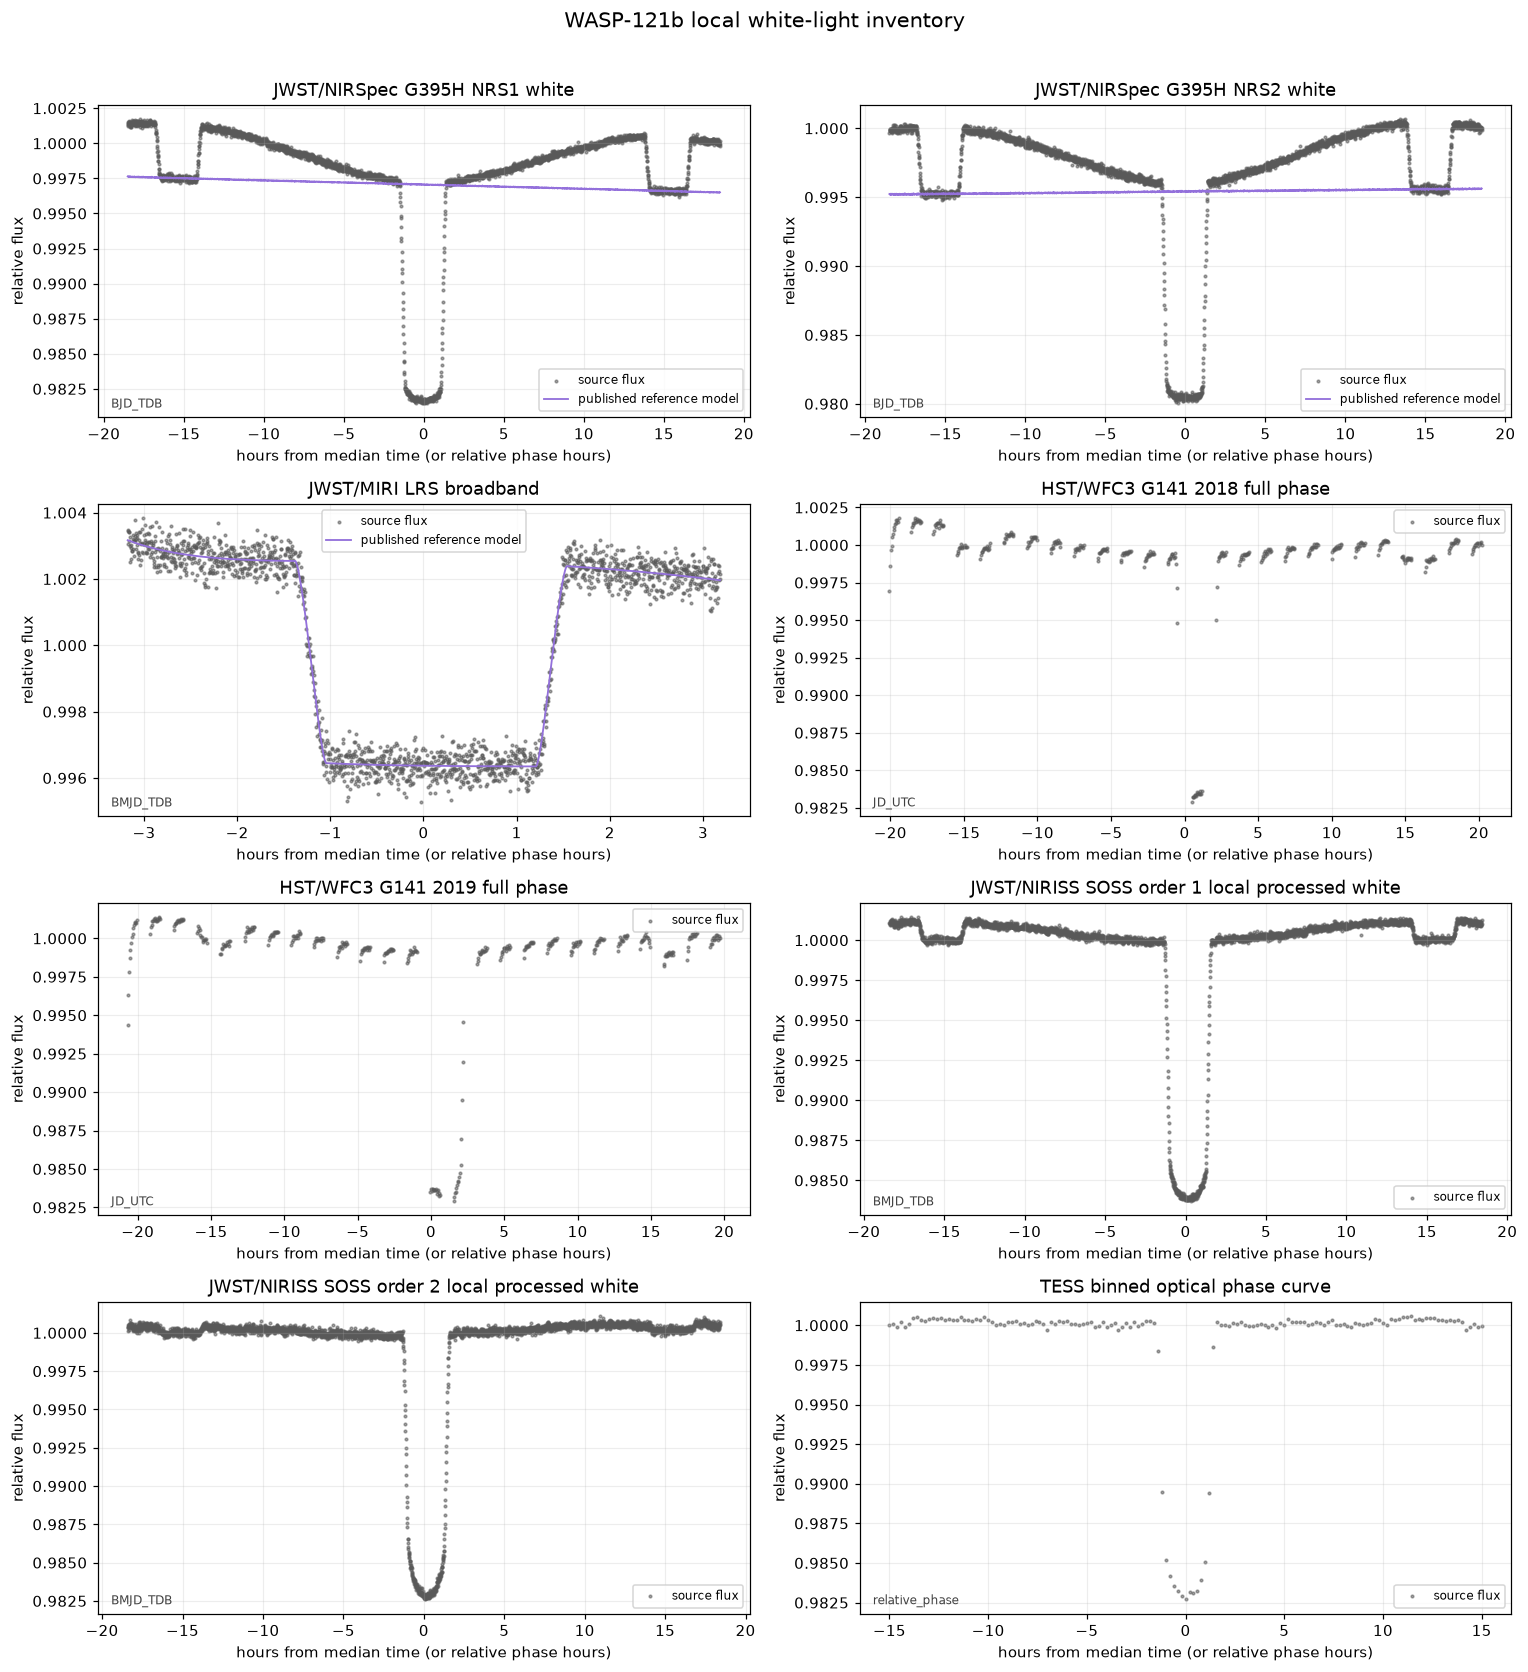

In [6]:
plot_order = ['nirspec_nrs1', 'nirspec_nrs2', 'miri_broadband', 'hst_g141_2018', 'hst_g141_2019', 'soss_order1', 'soss_order2', 'tess']
fig, axes = plt.subplots(4, 2, figsize=(14, 15))
axes = axes.ravel()
for ax, key in zip(axes, plot_order):
    item = DATA.get(key)
    if item is None:
        ax.text(0.5, 0.5, 'data not local', ha='center', va='center')
        ax.set_title(key)
        continue
    x = item['x_hours']
    ax.scatter(x, item['flux'], s=3, color='0.35', alpha=0.55, rasterized=True, label='source flux')
    if 'systematics_model' in item:
        ax.plot(x, item['systematics_model'], color=MEDIUMPURPLE, lw=1.2, label='published reference model')
    ax.set_title(item['label'])
    ax.set_xlabel('hours from median time (or relative phase hours)')
    ax.set_ylabel('relative flux')
    ax.legend(loc='best', fontsize=8)
    ax.text(0.02, 0.03, item['time_system'], transform=ax.transAxes, fontsize=8, color='0.25')
for ax in axes[len(plot_order):]:
    ax.set_visible(False)
fig.suptitle('WASP-121b local white-light inventory', y=1.01, fontsize=14)
fig.tight_layout()
plt.show()

### Instrument-specific systematics clues

The next plot shows the nuisance terms that are available in the local prepared products. Use these curves to learn the structure of the data, not to copy the published correction blindly.

- NIRSpec has pointing jitter columns in the source products.
- MIRI has a polynomial baseline, an exponential ramp, and an astrophysical model.
- HST, SOSS, and TESS do not have complete detector-level regressors in the local white products. That limits what can be claimed from those products alone.

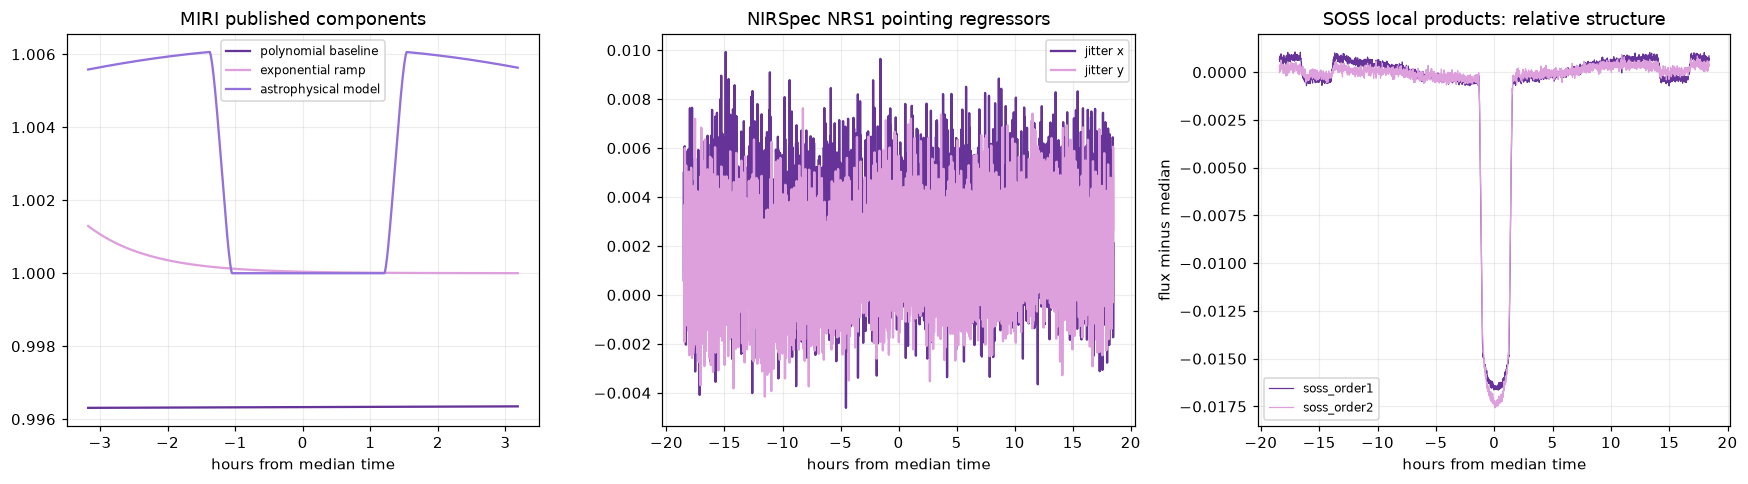

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

miri = DATA.get('miri_broadband')
if miri is not None:
    x = miri['x_hours']
    axes[0].plot(x, miri['polynomial'], label='polynomial baseline', color='rebeccapurple')
    axes[0].plot(x, miri['exponential_ramp'], label='exponential ramp', color='plum')
    axes[0].plot(x, miri['astrophysical_model'], label='astrophysical model', color=MEDIUMPURPLE)
    axes[0].set_title('MIRI published components')
    axes[0].set_xlabel('hours from median time')
    axes[0].legend(fontsize=8)
else:
    axes[0].text(0.5, 0.5, 'MIRI product not local', ha='center', va='center')

nrs1 = DATA.get('nirspec_nrs1')
if nrs1 is not None:
    x = nrs1['x_hours']
    # The white prepared product keeps the jitter values in the spectral package.
    spectral_path = repo_path('literature_data', 'WASP-121b', 'JWST-NIRSpec-G395H', 'prepared', 'spectroscopic', 'nrs1_spectroscopic.npz')
    if spectral_path.is_file():
        with np.load(spectral_path, allow_pickle=False) as archive:
            jitter_x = np.interp(nrs1['time'], archive['data_time'], archive['jitter_x'])
            jitter_y = np.interp(nrs1['time'], archive['data_time'], archive['jitter_y'])
            axes[1].plot(x, jitter_x, label='jitter x', color='rebeccapurple')
            axes[1].plot(x, jitter_y, label='jitter y', color='plum')
        axes[1].set_title('NIRSpec NRS1 pointing regressors')
        axes[1].set_xlabel('hours from median time')
        axes[1].legend(fontsize=8)
    else:
        axes[1].text(0.5, 0.5, 'NIRSpec spectral package not local', ha='center', va='center')
else:
    axes[1].text(0.5, 0.5, 'NRS1 product not local', ha='center', va='center')

for key, colour in [('soss_order1', 'rebeccapurple'), ('soss_order2', 'plum')]:
    if key in DATA:
        axes[2].plot(DATA[key]['x_hours'], DATA[key]['flux'] - np.median(DATA[key]['flux']), label=key, color=colour, lw=0.8)
axes[2].set_title('SOSS local products: relative structure')
axes[2].set_xlabel('hours from median time')
axes[2].set_ylabel('flux minus median')
axes[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 9. Full phase curves and arbitrary event counts

The map code must support a time series that contains any number of transits and eclipses. We do not assume one eclipse. We compute the event centres from the period and transit epoch, then count which centres lie inside the observed interval.

For a circular orbit, transit centres occur at phase 0 and secondary-eclipse centres at phase 0.5. For eccentric orbits, replace this simple rule with the full orbital model.

In [8]:
PERIOD_DAYS = 1.27492504
TRANSIT_EPOCH_BJD_TDB = 2458119.72074

def event_centres(bjd, period_days=PERIOD_DAYS, transit_epoch=TRANSIT_EPOCH_BJD_TDB):
    bjd = np.asarray(bjd, dtype=float)
    lo, hi = float(np.nanmin(bjd)), float(np.nanmax(bjd))
    k0 = int(np.floor((lo - transit_epoch) / period_days)) - 2
    k1 = int(np.ceil((hi - transit_epoch) / period_days)) + 2
    k = np.arange(k0, k1 + 1)
    transit = transit_epoch + k * period_days
    eclipse = transit_epoch + (k + 0.5) * period_days
    return {
        'transit': transit[(transit >= lo) & (transit <= hi)],
        'eclipse': eclipse[(eclipse >= lo) & (eclipse <= hi)],
        'interval': (lo, hi),
    }

for key, item in DATA.items():
    if item['phase_bjd'] is None:
        hours = item.get('phase_relative_hours', item['x_hours'])
        secondary_hours = PERIOD_DAYS * 24.0 / 2.0
        print(f'{key:18s} phase-folded product: transit at 0 h; nominal eclipse centre at {secondary_hours:.3f} h; table range {np.min(hours):.3f} to {np.max(hours):.3f} h')
        continue
    events = event_centres(item['phase_bjd'])
    print(f'{key:18s} transits={len(events["transit"]):2d} eclipses={len(events["eclipse"]):2d} | interval={events["interval"][0]:.5f} to {events["interval"][1]:.5f}')

nirspec_nrs1       transits= 1 eclipses= 2 | interval=2459866.87430 to 2459868.41631
nirspec_nrs2       transits= 1 eclipses= 2 | interval=2459866.87433 to 2459868.41634
miri_broadband     transits= 0 eclipses= 1 | interval=2460411.26268 to 2460411.52754
hst_g141_2018      transits= 1 eclipses= 2 | interval=2458190.24372 to 2458191.92077
hst_g141_2019      transits= 1 eclipses= 2 | interval=2458517.86977 to 2458519.55280
soss_order1        transits= 1 eclipses= 2 | interval=2460244.24775 to 2460245.78167
soss_order2        transits= 1 eclipses= 2 | interval=2460244.24775 to 2460245.78167
tess               phase-folded product: transit at 0 h; nominal eclipse centre at 15.299 h; table range -14.999 to 15.001 h


## 10. Why maps are separate before they are joint

A map is a wavelength-dependent brightness model. It is not a correction for an instrument. If NIRSpec, MIRI, HST, SOSS, and TESS are placed in one likelihood before their nuisance models are tested, a detector ramp can look like a hot spot.

Use this order:

1. Fit one white light curve per unique detector, order, visit, or instrument.
2. Fit representative spectral bins with the matching systematics regressors.
3. Compare residuals, uncertainty scaling, posterior diagnostics, and hot-spot definitions.
4. Combine only the validated maps in a hierarchical model.
5. Use shared orbital parameters where justified, but allow wavelength-dependent map coefficients and hot-spot offsets.

For a phase curve, longitude is usually better constrained than latitude. A north-south harmonic can have a weak or nearly invisible effect on the time series. Use an active-harmonic list or a regularising prior that makes this limitation explicit. Do not interpret a noisy latitude maximum as a secure atmospheric structure.

## 11. Map and brightness-temperature utilities

The sampler produces a map in brightness or flux-ratio units. A brightness temperature is a derived quantity. It depends on wavelength, the stellar temperature, and the assumed radius ratio. It is not the same as a retrieved physical temperature profile.

The helper below uses a simple Planck-ratio inversion for teaching. A production analysis must use the bandpass-integrated forward model and record the assumptions. The map plot uses `Purples_r`: larger values are lighter, so hotter or brighter areas are lighter purple. The sub-stellar point is longitude 0 degrees. Both map plots mark the meridionally averaged hot-spot longitude with its asymmetric error bar. This marker is placed at latitude 0 because the profile statistic does not measure hot-spot latitude. The longitude plot also shows the published comparison value.

In [9]:
H_PLANCK = 6.62607015e-34
C_LIGHT = 299792458.0
K_BOLTZMANN = 1.380649e-23

def brightness_temperature_from_ratio(fp_over_fs, wavelength_micron, radius_ratio=0.123, stellar_temperature=6460.0):
    fp_over_fs = np.asarray(fp_over_fs, dtype=float)
    wavelength_m = np.asarray(wavelength_micron, dtype=float) * 1e-6
    q = np.maximum(fp_over_fs / (radius_ratio ** 2), 1e-12)
    x_star = H_PLANCK * C_LIGHT / (wavelength_m * K_BOLTZMANN * stellar_temperature)
    with np.errstate(over='ignore', divide='ignore', invalid='ignore'):
        x_planet = np.log1p(np.expm1(np.clip(x_star, 0.0, 700.0)) / q)
        temperature = H_PLANCK * C_LIGHT / (wavelength_m * K_BOLTZMANN * x_planet)
    return temperature

def plot_mollweide_map(longitude_degrees, latitude_degrees, values, title, colour_label='brightness', hotspot_degrees=None, hotspot_q16=None, hotspot_q84=None):
    longitude_degrees = np.asarray(longitude_degrees, dtype=float)
    latitude_degrees = np.asarray(latitude_degrees, dtype=float)
    values = np.asarray(values, dtype=float)
    lon, lat = np.meshgrid(np.deg2rad(longitude_degrees), np.deg2rad(latitude_degrees))
    fig, ax = plt.subplots(figsize=(9, 4.8), subplot_kw={'projection': 'mollweide'})
    mesh = ax.pcolormesh(lon, lat, values, cmap=PURPLE_CMAP, shading='auto')
    ax.axvline(0.0, color='black', lw=1.1, ls='--')
    ax.scatter([0.0], [0.0], color='black', s=24, zorder=5)
    ax.annotate('sub-stellar point', (0.0, 0.0), xytext=(8, 8), textcoords='offset points', fontsize=9)
    if hotspot_degrees is not None:
        hotspot_radians = np.deg2rad(float(hotspot_degrees))
        xerr = None
        if hotspot_q16 is not None and hotspot_q84 is not None:
            xerr = np.deg2rad(np.array([[hotspot_degrees - hotspot_q16], [hotspot_q84 - hotspot_degrees]]))
        ax.errorbar([hotspot_radians], [0.0], xerr=xerr, fmt='o', color=MEDIUMPURPLE, mec='black', capsize=4, zorder=6)
        ax.annotate(f'profile hot spot: {hotspot_degrees:.2f} deg', (hotspot_radians, 0.0), xytext=(8, -18), textcoords='offset points', fontsize=9, color='black')
    ax.set_title(title)
    ax.set_xlabel('longitude: east positive')
    ax.set_ylabel('latitude')
    fig.colorbar(mesh, ax=ax, label=colour_label, pad=0.08)
    fig.tight_layout()
    return fig, ax

def plot_longitude_profile(longitude_degrees, profile, hotspot_degrees=None, hotspot_q16=None, hotspot_q84=None, published_degrees=None, published_error=None, title='Longitude profile'):
    longitude_degrees = np.asarray(longitude_degrees, dtype=float)
    profile = np.asarray(profile, dtype=float)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(longitude_degrees, profile, color=MEDIUMPURPLE, lw=2, label='robert-mapping profile')
    ax.axvline(0.0, color='black', ls='--', lw=1.1, label='sub-stellar point (0 deg)')
    if hotspot_degrees is not None:
        y = float(np.interp(hotspot_degrees, longitude_degrees, profile))
        xerr = None
        if hotspot_q16 is not None and hotspot_q84 is not None:
            xerr = np.array([[hotspot_degrees - hotspot_q16], [hotspot_q84 - hotspot_degrees]])
        ax.errorbar([hotspot_degrees], [y], xerr=xerr, fmt='o', color=MEDIUMPURPLE, mec='black', capsize=4, label=f'robert-mapping hot spot: {hotspot_degrees:.2f} deg')
    if published_degrees is not None:
        label = f'published comparison: {published_degrees:.2f} deg'
        if published_error is not None:
            ax.axvspan(published_degrees - published_error, published_degrees + published_error, color='darkorange', alpha=0.18, label=label)
        else:
            ax.axvline(published_degrees, color='darkorange', ls=':', lw=1.8, label=label)
    ax.set_xlim(-180, 180)
    ax.set_xlabel('longitude east of sub-stellar point (degrees)')
    ax.set_ylabel('meridionally averaged brightness')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='best')
    fig.tight_layout()
    return fig, ax

# Published values used as comparison annotations when the same longitude definition is used.
# NIRSpec values are from Mikal-Evans et al. (2023); SOSS values are from the local literature audit.
PUBLISHED_OFFSETS_DEG = {
    'nirspec_nrs1': {'value': 3.36, 'error': 0.11, 'source': 'Mikal-Evans et al. 2023'},
    'nirspec_nrs2': {'value': 2.66, 'error': 0.12, 'source': 'Mikal-Evans et al. 2023'},
    'soss_order1': {'value': 5.1, 'error': 1.4, 'source': 'NIRISS energy-budget study'},
    'soss_order2': {'value': 10.5, 'error': 9.9, 'source': 'NIRISS energy-budget study'},
}
print('Map and longitude plotting functions are ready.')
print('Example Planck conversion:', brightness_temperature_from_ratio(0.002, 3.5), 'K')

Map and longitude plotting functions are ready.
Example Planck conversion: 2010.1747134392474 K


### What to report from a completed fit

For every map, save:

- the white-light curve, best-fit model, residuals, and uncertainty scaling;
- the brightness map median and credible maps;
- the brightness-temperature map with its assumptions;
- the meridionally averaged longitude profile;
- the hot-spot longitude median, q16, and q84 values;
- the sub-stellar point at 0 degrees;
- the published comparison value and its error bar;
- divergences, R-hat, effective sample size, and chain agreement; and
- the full resolved configuration and input audit.

The longitude statistic must match the comparison paper. For Hammond-style reporting, use the maximum of the meridionally averaged dayside profile, not the two-dimensional pixel maximum. The two-dimensional maximum can be shown as a diagnostic, but it has weaker latitude meaning.

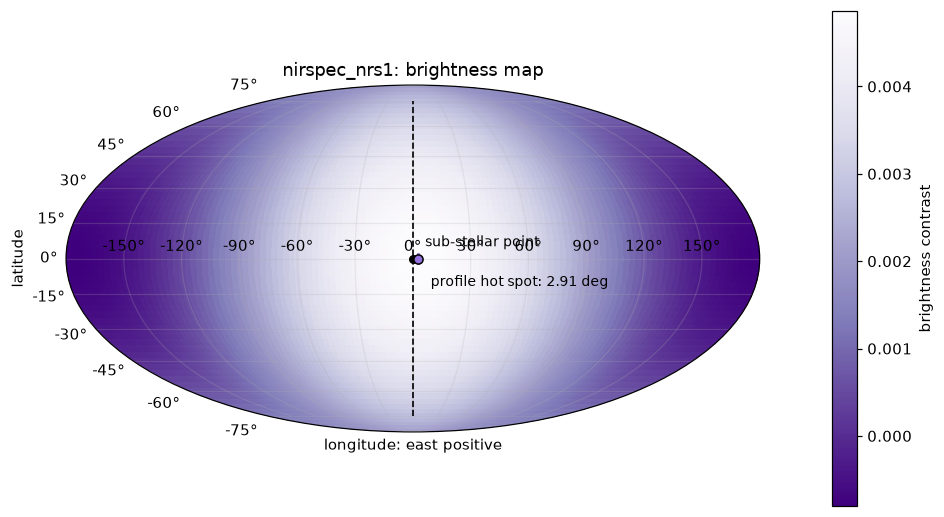

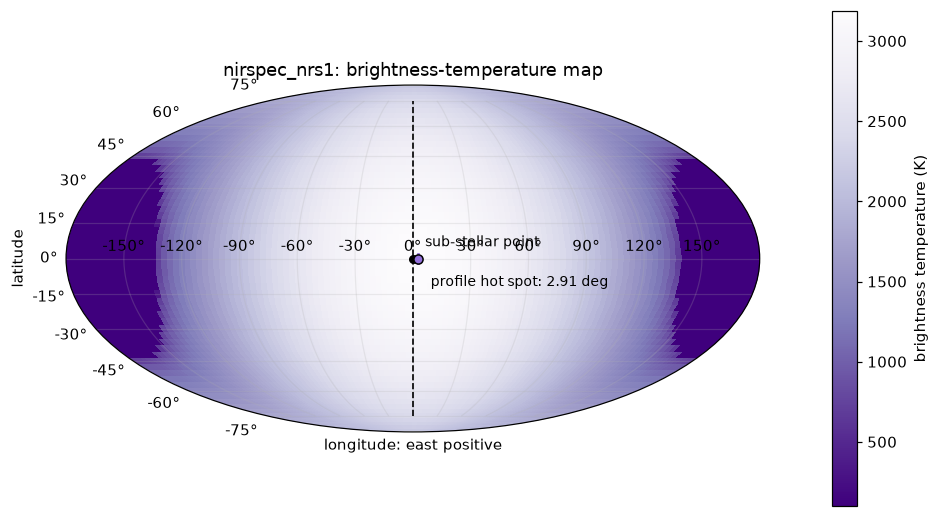

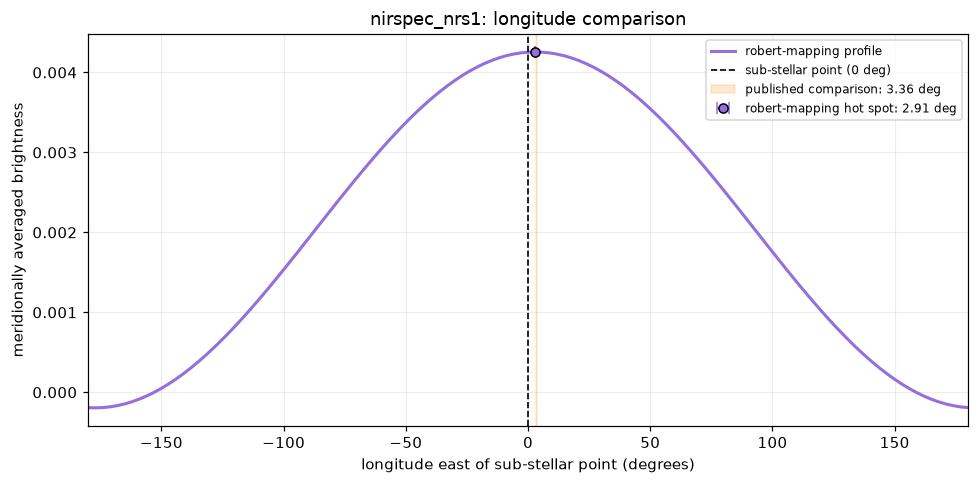

nirspec_nrs1: hot spot 2.905 deg, q16=2.796, q84=3.022
Published comparison: 3.360 +/- 0.110 deg (Mikal-Evans et al. 2023)


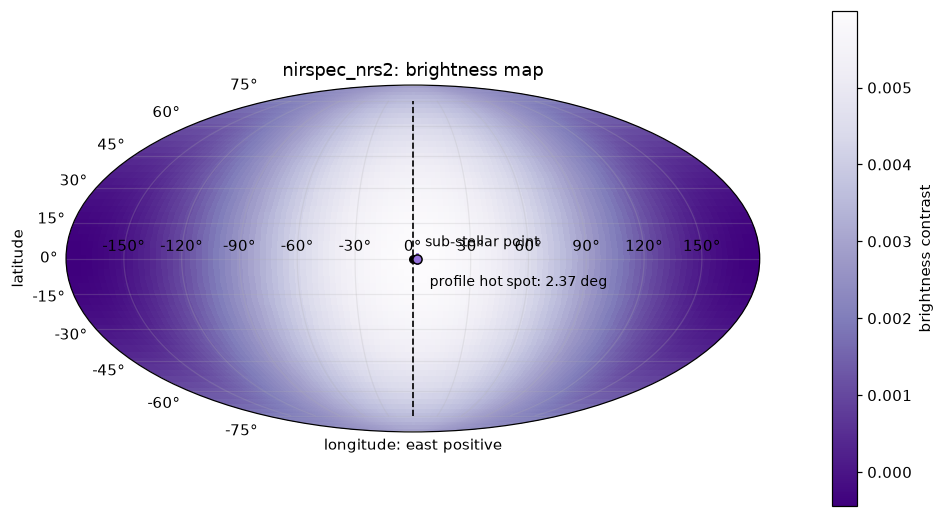

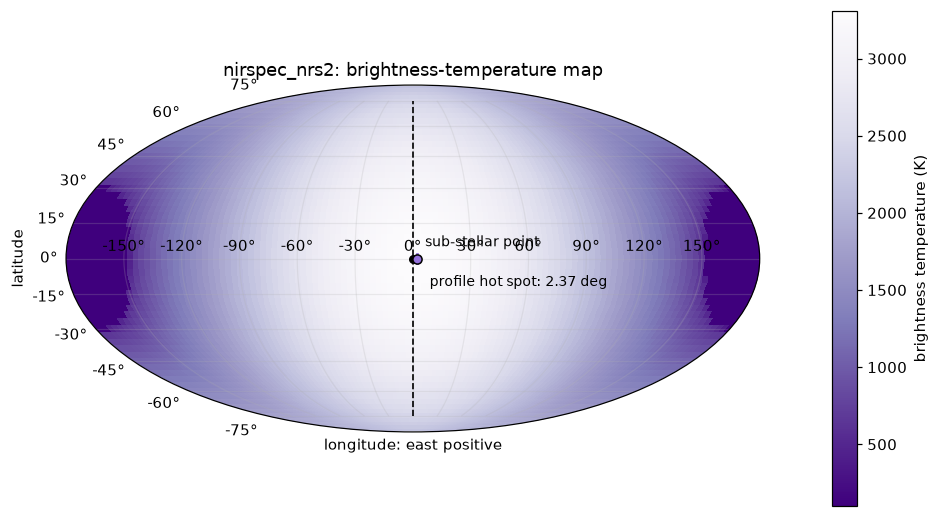

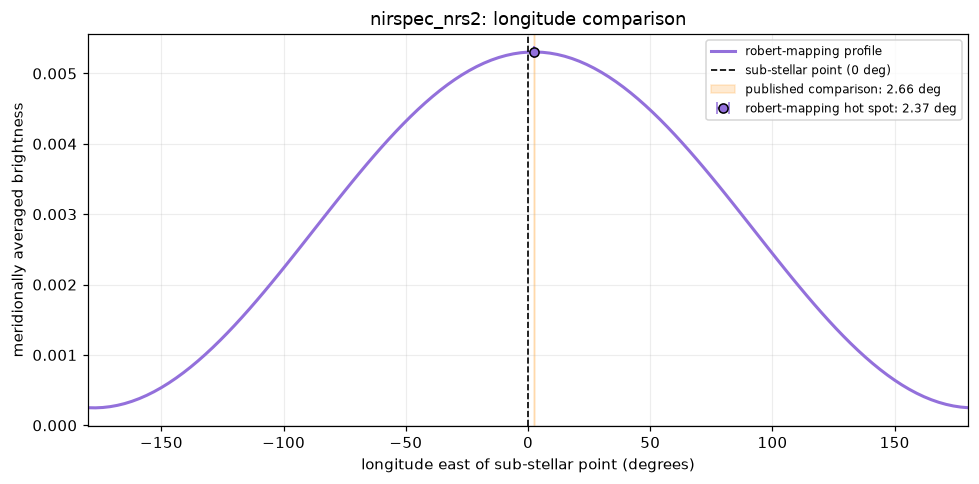

nirspec_nrs2: hot spot 2.374 deg, q16=2.258, q84=2.481
Published comparison: 2.660 +/- 0.120 deg (Mikal-Evans et al. 2023)


In [10]:
def saved_wasp121_map_dirs():
    candidates = {
        'nirspec_nrs1': REPO / 'results' / 'wasp121b_nrs1_validation',
        'nirspec_nrs2': REPO / 'results' / 'wasp121b_nrs2_validation',
        'miri_broadband': REPO / 'results' / 'wasp121b_miri_lrs_validation',
    }
    return {key: path for key, path in candidates.items() if (path / 'posterior_maps.npz').is_file()}

def plot_saved_map(key, result_dir):
    with np.load(result_dir / 'posterior_maps.npz', allow_pickle=False) as archive:
        lon = archive['longitude_degrees']
        lat = archive['latitude_degrees']
        contrast = archive['contrast_median']
        temperature = archive['temperature_median_kelvin']
        profile = archive['longitude_profile_median']
        hotspot_draws = archive['hotspot_longitude_degrees']
    hotspot_q16, hotspot, hotspot_q84 = np.quantile(hotspot_draws, [0.16, 0.50, 0.84])
    reference = PUBLISHED_OFFSETS_DEG.get(key, {})
    plot_mollweide_map(lon, lat, contrast, f'{key}: brightness map', 'brightness contrast', hotspot, hotspot_q16, hotspot_q84)
    plt.show()
    plot_mollweide_map(lon, lat, temperature, f'{key}: brightness-temperature map', 'brightness temperature (K)', hotspot, hotspot_q16, hotspot_q84)
    plt.show()
    plot_longitude_profile(
        lon, profile, hotspot_degrees=hotspot, hotspot_q16=hotspot_q16, hotspot_q84=hotspot_q84,
        published_degrees=reference.get('value'), published_error=reference.get('error'),
        title=f'{key}: longitude comparison',
    )
    plt.show()
    print(f'{key}: hot spot {hotspot:.3f} deg, q16={hotspot_q16:.3f}, q84={hotspot_q84:.3f}')
    if reference:
        print(f'Published comparison: {reference["value"]:.3f} +/- {reference["error"]:.3f} deg ({reference["source"]})')

MAP_DIRS = saved_wasp121_map_dirs()
if MAP_DIRS:
    for key, path in MAP_DIRS.items():
        plot_saved_map(key, path)
else:
    print('No completed WASP-121b posterior map files were found. The plotting functions above will display maps after a fit.')

## 12. Spectral bins and small batches

Spectral mapping is expensive because each bin has its own brightness parameters and nuisance coefficients. Start with a few representative bins. Keep the batch size small. Run jobs in sequence on a laptop.

The NIRSpec package has 146 NRS1 channels and 203 NRS2 channels. The MIRI package has 47 channels. The 2018 HST visit has 12 fit-ready prepared spectral channels. The public files named as 2019 HST spectral channels contain 2018 timestamps. The preparer keeps these files for audit but sets `fit_ready=False`. Do not use them until the correct source is available. The 2019 broadband curve is not affected by this specific archive error.

In [11]:
def spectral_inventory():
    groups = []
    nirspec_dir = REPO / 'literature_data' / 'WASP-121b' / 'JWST-NIRSpec-G395H' / 'prepared' / 'spectroscopic'
    for detector in ('nrs1', 'nrs2'):
        path = nirspec_dir / f'{detector}_spectroscopic.npz'
        if path.is_file():
            with np.load(path, allow_pickle=False) as archive:
                groups.append((f'NIRSpec {detector.upper()}', int(archive['flux'].shape[1]), float(np.min(archive['wavelength'])), float(np.max(archive['wavelength']))))
    miri_dir = REPO / 'literature_data' / 'WASP-121b' / 'JWST-MIRI-LRS' / 'prepared' / 'spectroscopic'
    miri_paths = sorted(miri_dir.glob('channel_*.npz'))
    if miri_paths:
        wavelengths = []
        for path in miri_paths:
            with np.load(path, allow_pickle=False) as archive:
                wavelengths.append(float(np.nanmedian(archive['wavelength_micron'])))
        groups.append(('MIRI LRS', len(miri_paths), min(wavelengths), max(wavelengths)))
    hst_prepared = REPO / 'literature_data' / 'WASP-121b' / 'HST-WFC3-G141' / 'prepared' / 'spectral'
    for visit in ('visit_2018', 'visit_2019'):
        paths = sorted((hst_prepared / visit).glob('channel_*.npz'))
        fit_ready = []
        wavelengths = []
        for path in paths:
            with np.load(path, allow_pickle=False) as archive:
                if bool(np.asarray(archive['fit_ready']).item()):
                    fit_ready.append(path)
                    wavelengths.append(float(np.asarray(archive['wavelength_centre_micron']).item()))
        if fit_ready:
            groups.append((f'HST G141 {visit[-4:]} fit-ready', len(fit_ready), min(wavelengths), max(wavelengths)))
        elif paths:
            print(f'HST G141 {visit[-4:]}: {len(paths)} archived channels, 0 fit-ready because source timestamps do not match the visit')
    return groups

def batches(items, batch_size=5):
    items = list(items)
    for start in range(0, len(items), batch_size):
        yield items[start:start + batch_size]

for label, count, lower, upper in spectral_inventory():
    print(f'{label:28s} bins={count:3d} wavelength={lower:.3f} to {upper:.3f} micron')

# This is a plan only. It does not run an inference.
example_jobs = [('nirspec_nrs1', 0), ('nirspec_nrs1', 72), ('nirspec_nrs2', 0), ('miri_broadband', 0)]
for number, batch in enumerate(batches(example_jobs, batch_size=2), start=1):
    print(f'planned sequential batch {number}: {batch}')

HST G141 2019: 12 archived channels, 0 fit-ready because source timestamps do not match the visit
NIRSpec NRS1                 bins=146 wavelength=2.728 to 3.710 micron
NIRSpec NRS2                 bins=203 wavelength=3.827 to 5.167 micron
MIRI LRS                     bins= 47 wavelength=5.075 to 11.925 micron
HST G141 2018 fit-ready      bins= 12 wavelength=1.158 to 1.616 micron
planned sequential batch 1: [('nirspec_nrs1', 0), ('nirspec_nrs1', 72)]
planned sequential batch 2: [('nirspec_nrs2', 0), ('miri_broadband', 0)]


## 13. Safe optional inference cell

Keep this cell unchanged while learning the data. It is intentionally disabled. To run a fit, edit one YAML file, validate it first, and set `RUN_INFERENCE = True`. Run one data set at a time.

The same rule applies to recovery tests. Recovery tests are simulations and are disabled here. Use them only after the real-data input audit.

In [12]:
RUN_INFERENCE = False
RUN_RECOVERY = False
FIT_CONFIG = REPO / 'examples' / 'validation_wasp121b_nrs1.yml'
RECOVERY_CONFIG = REPO / 'examples' / 'recovery_hatp32.yml'

if RUN_INFERENCE:
    import subprocess
    if not FIT_CONFIG.is_file():
        raise FileNotFoundError(f'Fit configuration is missing: {FIT_CONFIG}')
    environment = dict(os.environ)
    for name in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
        environment[name] = '3'
    print('Running one fit with a three-CPU limit:', FIT_CONFIG)
    subprocess.run([os.sys.executable, '-m', 'robert_mapping', 'fit', str(FIT_CONFIG)], cwd=REPO, env=environment, check=True)
else:
    print('RUN_INFERENCE is False: no posterior samples were drawn.')

if RUN_RECOVERY:
    import subprocess
    if not RECOVERY_CONFIG.is_file():
        raise FileNotFoundError(f'Recovery configuration is missing: {RECOVERY_CONFIG}')
    print('Recovery is enabled. Check the configuration and input before continuing:', RECOVERY_CONFIG)
    subprocess.run([os.sys.executable, '-m', 'robert_mapping', 'recover', str(RECOVERY_CONFIG), '--dry-run'], cwd=REPO, env=environment, check=True)
else:
    print('RUN_RECOVERY is False: no simulated data were made.')

RUN_INFERENCE is False: no posterior samples were drawn.
RUN_RECOVERY is False: no simulated data were made.


## 14. Validation and injection-recovery tests

A working sampler is not enough. Use a short, repeatable validation ladder:

1. Physics check: compare the ported occultation operator with the frozen one-to-one starry reference.
2. Input check: verify shapes, masks, units, time conversion, and checksum or archive provenance.
3. White-light check: fit a uniform map and inspect the residuals.
4. Map check: fit a low-degree map with small sampling.
5. Posterior check: require zero or understood divergences, stable R-hat, adequate effective sample size, and agreement between chains.
6. Recovery check: inject a known longitude into a matching cadence and noise model. The credible interval should cover the injected value at the stated rate.
7. Rejection check: inject no hot spot or a uniform map. The model should not create a repeated false hot-spot detection.
8. Systematics check: repeat the recovery with the instrument nuisance terms. A map signal that disappears when the correct ramp or jitter model is added is a systematics warning.

Record the injected longitude, map degree, noise seed, sampling settings, CPU limit, recovered q16/median/q84, residual RMS, divergences, R-hat, and effective sample size. Keep mapping evidence separate from a conditional longitude estimate.

## 15. Applying this study to a new planet

Use this checklist before you add a new target:

- [ ] Create `literature_data/<planet>/<instrument>/<observation>` folders.
- [ ] Record the paper DOI, archive DOI, observation ID, detector, order, visit, and photon set.
- [ ] Decide which products are raw, systematics-corrected, published model tables, or binned phase curves.
- [ ] Record the time standard and offset. Never infer BJD from a column name alone.
- [ ] Preserve the original rows and source masks.
- [ ] Record exposure time and integration treatment.
- [ ] Count every transit and eclipse in the time range.
- [ ] Build an instrument-specific systematics model before a production map fit.
- [ ] Validate the white-light curve with a uniform model.
- [ ] Fit a small low-degree map and inspect longitude versus latitude information.
- [ ] Use a reversed purple map colour scale: lighter means hotter or brighter.
- [ ] Label the sub-stellar point and the hot-spot offset with asymmetric error bars.
- [ ] Add the published comparison only when the statistic and sign convention match.
- [ ] Run one-to-one physics, recovery, and rejection tests.
- [ ] Store the resolved YAML, input audit, posterior diagnostics, plots, and environment details.
- [ ] Increase sampling only after the small run is stable.

The student should copy this notebook, change the inventory and configuration cells, and keep the audit sections. The audit is part of the scientific result.

## References and local provenance

- Mikal-Evans et al. (2023), JWST/NIRSpec G395H full phase curve: https://arxiv.org/abs/2301.03209
- Mikal-Evans et al. (2021), HST/WFC3 G141 full phase curves: https://www.nature.com/articles/s41550-021-01592-w
- JWST/NIRISS SOSS full phase curve: https://arxiv.org/abs/2509.09760
- JWST/MIRI LRS eclipse: https://arxiv.org/abs/2606.21855
- Spitzer phase curves: https://arxiv.org/abs/2307.00669
- TESS optical phase curve: https://arxiv.org/abs/1909.03010
- SMARTS K-band eclipse: https://doi.org/10.1051/0004-6361/201834059
- Full local and archive inventory: `literature_data/wasp121b_suite.yml`
- Student preparation guide: `docs/wasp121b_observation_suite.md`

This notebook does not download files. Use the catalog URLs and the preparation tools. Verify checksums before a fit. Missing source data stay marked as missing. Do not make placeholder observations.